# Comprehensive Language Embedding Analysis

This notebook consolidates the entire pipeline for analyzing Llama-3 language embeddings, from data preprocessing and embedding generation to advanced clustering and evaluation.

## Objectives:
1.  **Data Preprocessing**: Filter FineWeb-2 languages and assign resource tiers.
2.  **Embedding Generation**: Generate semantic embeddings using Llama-3.2-1B.
3.  **Dimensionality Reduction**: Visualize embeddings using UMAP and t-SNE.
4.  **Clustering**: Apply K-Means, HDBSCAN, and Hierarchical Clustering to identify language families.
5.  **Evaluation**: Assess clustering quality against genealogical data using rigorous metrics (AMI, NMI, ARI) and interactive visualizations.

In [1]:
# Imports
import os
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from tqdm import tqdm
from enum import Enum
from transformers import AutoTokenizer, AutoModel
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples, pairwise_distances
from sklearn.metrics import homogeneity_score, adjusted_mutual_info_score, normalized_mutual_info_score, adjusted_rand_score, confusion_matrix
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Setup Paths
PROJECT_ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../..'))
if PROJECT_ROOT_DIR not in sys.path:
    sys.path.append(PROJECT_ROOT_DIR)

DATA_DIR = os.path.join(os.getcwd(), "processed_artifacts")
BASE_DATA_DIR = os.path.join(os.getcwd(), "base_data")
os.makedirs(DATA_DIR, exist_ok=True)

from approaches.CoLA.distributed_data_processor.language_subsets import fineweb2_benchmark_languages

print("Environment Setup Complete.")

/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment Setup Complete.


## Part 1: Data Preprocessing
Load FineWeb-2 metadata, filter for benchmark languages, and attach resource categories.

In [2]:
class ResourceCategory(str, Enum):
    HIGH = "high"
    MEDIUM = "medium"
    LOW = "low"

def load_and_filter_metadata(csv_path, benchmark_languages):
    """Load FineWeb-2 metadata and keep only evaluable languages."""
    df = pd.read_csv(csv_path)
    mask = (
        ~df["subset"].astype(str).str.endswith("_removed")
        & (df["split"] == "train")
        & (df["family"] != "-")
    )
    df = df.loc[mask].reset_index(drop=True)
    df = df[df["subset"].isin(benchmark_languages)].reset_index(drop=True)
    print(f"Loaded {len(df)} evaluable languages.")
    return df

def add_resource_categories(df, resource_csv_path):
    """Attach High/Medium/Low resource categories."""
    res_df = pd.read_csv(resource_csv_path, sep="\t")
    res_df = res_df[~res_df["resource_category"].str.endswith("*", na=False)]

    df["_subset_lc"] = df["subset"].astype(str).str.lower()
    res_df["_lang_code_lc"] = res_df["lang_code"].astype(str).str.lower()

    df = df.merge(
        res_df[["_lang_code_lc", "resource_category"]],
        left_on="_subset_lc",
        right_on="_lang_code_lc",
        how="left",
    )
    df.drop(columns=["_subset_lc", "_lang_code_lc"], inplace=True)
    df = df.sort_values(by="documents", ascending=False).reset_index(drop=True)

    # Fill logic (simplified from original script for brevity but functionally equivalent)
    # Here we assume the merge captured most, and we fill gaps if needed or use the complex logic if preferred.
    # For exact reproduction, let's use the logic from the script.
    last_rows = df.groupby("resource_category", dropna=False).tail(1)
    last_idx_by_category = {row["resource_category"]: row.name for _, row in last_rows.iterrows()}

    MERGE_MAP = {
        "high": ResourceCategory.HIGH,
        "medhigh": ResourceCategory.MEDIUM,
        "medlow": ResourceCategory.LOW,
        "low": ResourceCategory.LOW,
        "not_enough": ResourceCategory.LOW,
    }

    tuples = sorted(
        [(MERGE_MAP.get(k, ResourceCategory.LOW).value, v) for k, v in last_idx_by_category.items()],
        key=lambda x: x[1],
    )

    prev = 0
    for cat, end_idx in tuples:
        df.loc[prev:end_idx, "resource_category"] = cat
        prev = end_idx + 1
    if prev < len(df):
        df.loc[prev:, "resource_category"] = df["resource_category"].ffill()
    return df

# Execute Preprocessing
metadata_path = os.path.join(BASE_DATA_DIR, "fineweb2-language-distribution.csv")
resource_path = os.path.join(BASE_DATA_DIR, "lang_resource_dataset.tsv")

metadata = load_and_filter_metadata(metadata_path, fineweb2_benchmark_languages)
metadata = add_resource_categories(metadata, resource_path)

print("\nResource tiers:")
print(metadata["resource_category"].value_counts())
print("\nTop families:")
print(metadata["family"].value_counts().head(10))

Loaded 191 evaluable languages.

Resource tiers:
resource_category
low       135
high       31
medium     25
Name: count, dtype: int64

Top families:
family
Indo-European    76
Niger-Congo      32
Austronesian     18
Afro-Asiatic     18
Turkic           11
Sino-Tibetan      6
Creole            5
Dravidian         4
Nilo-Saharan      4
Kra-Dai           3
Name: count, dtype: int64


## Part 2: Embedding Generation (Llama-3)
Generate embeddings using `meta-llama/Llama-3.2-1B`. If embeddings already exist in `processed_artifacts/llm_embeddings.csv`, they will be loaded to save time.

In [3]:
def get_device():
    if torch.cuda.is_available():
        return "cuda"
    elif torch.backends.mps.is_available():
        return "mps"
    return "cpu"

def generate_embedding(text, tokenizer, model, device):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    last_hidden_states = outputs.last_hidden_state
    attention_mask = inputs["attention_mask"]
    last_token_indices = attention_mask.sum(dim=1) - 1
    batch_embeddings = []
    for i, idx in enumerate(last_token_indices):
        embedding = last_hidden_states[i, idx, :].cpu().numpy()
        batch_embeddings.append(embedding)
    return batch_embeddings[0]

emb_path = os.path.join(DATA_DIR, "llm_embeddings.csv")

if os.path.exists(emb_path):
    print(f"Loading existing embeddings from {emb_path}...")
    emb_df = pd.read_csv(emb_path)
    X = emb_df.values
else:
    print("Generating new embeddings...")
    device = get_device()
    print(f"Using device: {device}")
    
    model_name = "meta-llama/Llama-3.2-1B"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = AutoModel.from_pretrained(model_name, torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32, device_map="auto")
    model.eval()
    
    embeddings = []
    for _, row in tqdm(metadata.iterrows(), total=len(metadata)):
        text = (
            f"Language: {row.get('name', 'Unknown')}. "
            f"Script: {row.get('script', 'Unknown')}. "
            f"Family: {row.get('family', 'Unknown')}. "
            f"Resource Level: {row.get('resource_category', 'Unknown')}."
        )
        emb = generate_embedding(text, tokenizer, model, device)
        embeddings.append(emb)
    
    emb_df = pd.DataFrame(embeddings)
    emb_df.columns = [f"llm_emb_{i}" for i in range(emb_df.shape[1])]
    emb_df.to_csv(emb_path, index=False)
    X = emb_df.values
    print("Embeddings generated and saved.")

print(f"Embedding Matrix Shape: {X.shape}")

Loading existing embeddings from /home/ubuntu/dice_repos/HTYLLM-PG/approaches/CoLA/data_prep/processed_artifacts/llm_embeddings.csv...
Embedding Matrix Shape: (191, 2048)


## Part 3: Dimensionality Reduction & Visualization
Compute t-SNE and UMAP projections for visualization.

In [4]:
# --- t-SNE ---
print("Computing t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)
metadata["TSNE1"] = X_tsne[:, 0]
metadata["TSNE2"] = X_tsne[:, 1]

# --- UMAP ---
print("Computing UMAP...")
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    X_umap = reducer.fit_transform(X)
    metadata["UMAP1"] = X_umap[:, 0]
    metadata["UMAP2"] = X_umap[:, 1]
except ImportError:
    print("UMAP not found. Installing umap-learn...")
    # !pip install umap-learn
    # import umap
    # reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    # X_umap = reducer.fit_transform(X)
    # metadata["UMAP1"] = X_umap[:, 0]
    # metadata["UMAP2"] = X_umap[:, 1]
    print("Skipping UMAP for now (install manually if needed).")
    metadata["UMAP1"] = 0.0
    metadata["UMAP2"] = 0.0
except Exception as e:
    print(f"UMAP failed: {e}")
    metadata["UMAP1"] = 0.0
    metadata["UMAP2"] = 0.0

def create_hover_template(projection_name="TSNE"):
    return "<b>%{hovertext}</b><br>" + \
           f"{projection_name}1: %{{customdata[0]:.3f}}<br>" + \
           f"{projection_name}2: %{{customdata[1]:.3f}}<br>" + \
           "Family: %{customdata[2]}<br>" + \
           "Resource: %{customdata[3]}<br>" + \
           "<extra></extra>"

def plot_projection(projection_name, x_col, y_col):
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=metadata[x_col],
        y=metadata[y_col],
        mode='markers',
        marker=dict(
            size=8,
            color=metadata["family"].astype('category').cat.codes,
            colorscale='Turbo',
            opacity=0.7,
            showscale=False
        ),
        text=metadata["name"],
        customdata=metadata[[x_col, y_col, "family", "resource_category"]],
        hovertemplate=create_hover_template(projection_name),
        name='Languages'
    ))
    fig.update_layout(
        title=f"Language Embeddings - {projection_name} Projection",
        width=1000,
        height=700,
        hoverlabel=dict(bgcolor="white", font_size=12)
    )
    fig.show()

plot_projection("t-SNE", "TSNE1", "TSNE2")
if "UMAP1" in metadata.columns and metadata["UMAP1"].sum() != 0:
    plot_projection("UMAP", "UMAP1", "UMAP2")

Computing t-SNE...
Computing UMAP...


/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Part 4: Clustering Analysis
Explore the structure of the embedding space using K-Means, HDBSCAN, and Hierarchical Clustering.

Running Silhouette Analysis for K-Means...


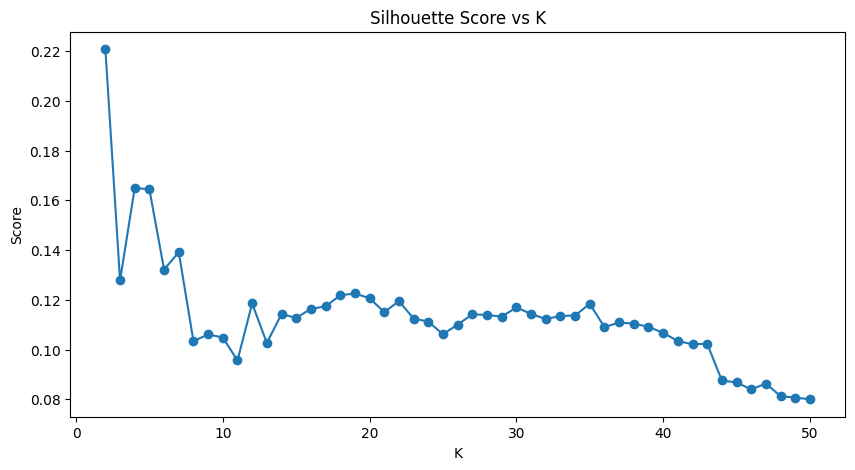

Optimal K based on max silhouette: 2
Optimal K (2) is too small. Using K=4 for broad grouping.
K-Means clustering complete (K=4).


In [5]:
# 1. K-Means Silhouette Analysis
scores = []
K_range = range(2, 51)
print("Running Silhouette Analysis for K-Means...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(K_range, scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

optimal_k = K_range[np.argmax(scores)]
print(f"Optimal K based on max silhouette: {optimal_k}")

# Force K=4 if optimal is too small (as per previous analysis preference)
if optimal_k < 4:
    print(f"Optimal K ({optimal_k}) is too small. Using K=4 for broad grouping.")
    optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init="auto", random_state=42)
metadata["kmeans_cluster"] = kmeans.fit_predict(X)
print(f"K-Means clustering complete (K={optimal_k}).")

In [6]:
# 2. HDBSCAN (Original High-Dim)
try:
    import hdbscan
    print("Running HDBSCAN on original embeddings...")
    clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5, gen_min_span_tree=True)
    metadata["hdbscan_cluster"] = clusterer.fit_predict(X)
    n_clusters = len(set(metadata["hdbscan_cluster"])) - (1 if -1 in metadata["hdbscan_cluster"] else 0)
    print(f"HDBSCAN found {n_clusters} clusters.")
except ImportError:
    print("HDBSCAN not installed.")

Running HDBSCAN on original embeddings...
HDBSCAN found 4 clusters.


/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



Running PCA (reducing to 50 dims)...
Explained Variance Ratio (First 50 components): 0.9373
Tuned HDBSCAN (PCA+Norm) found 9 clusters.
Running Hierarchical Clustering (Ward on PCA)...


/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



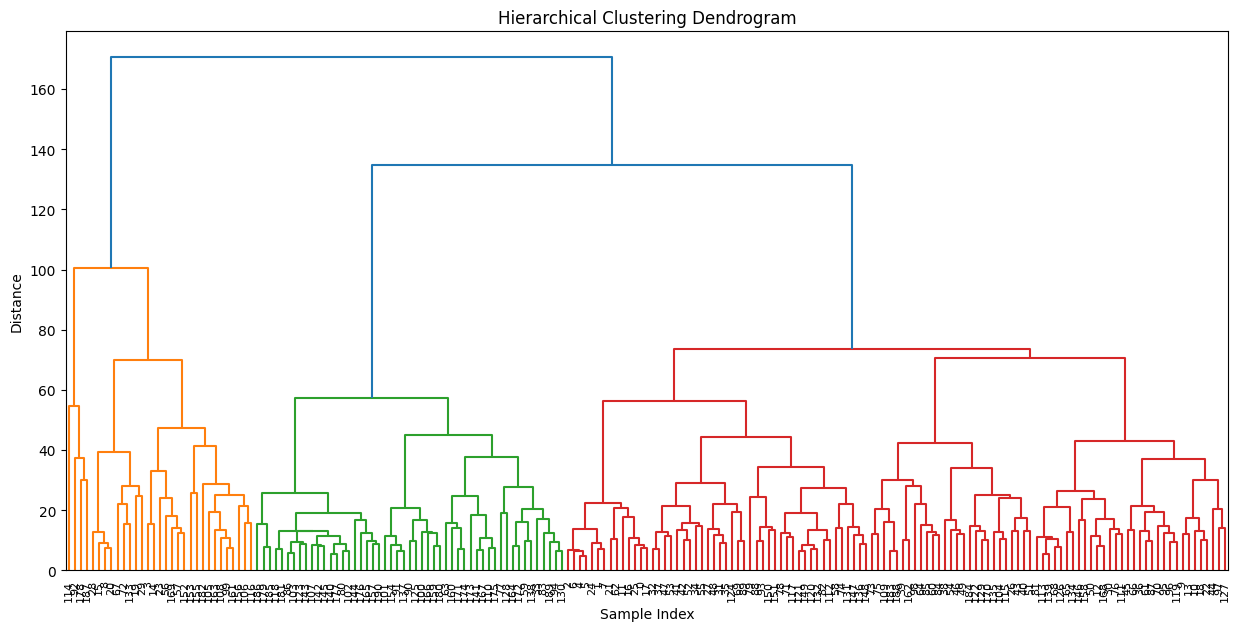

In [7]:
# 3. Refined Pipeline: PCA + HDBSCAN + Hierarchical
print("Running PCA (reducing to 50 dims)...")
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)
print(f"Explained Variance Ratio (First 50 components): {sum(pca.explained_variance_ratio_):.4f}")

# Tuned HDBSCAN on PCA
try:
    import hdbscan
    # Normalize for cosine-like distance with Euclidean metric
    X_pca_norm = normalize(X_pca)
    clusterer_tuned = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=2, metric='euclidean', gen_min_span_tree=True)
    metadata["hdbscan_tuned"] = clusterer_tuned.fit_predict(X_pca_norm)
    n_clusters_tuned = len(set(metadata["hdbscan_tuned"])) - (1 if -1 in metadata["hdbscan_tuned"] else 0)
    print(f"Tuned HDBSCAN (PCA+Norm) found {n_clusters_tuned} clusters.")
except ImportError:
    pass

# Hierarchical Clustering (Ward on PCA)
print("Running Hierarchical Clustering (Ward on PCA)...")
Z = linkage(X_pca, method='ward')
plt.figure(figsize=(15, 7))
plt.title("Hierarchical Clustering Dendrogram")
dendrogram(Z, labels=metadata.index, leaf_rotation=90., leaf_font_size=8.)
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

## Part 5: Evaluation & Interpretation
Evaluate clustering performance using ground-truth language families.

In [8]:
def print_metrics(name, labels, true_labels):
    # Filter noise for purity check
    mask = labels != -1
    if mask.sum() < 2:
        print(f"{name}: Not enough data (mostly noise)")
        return
    l_pred = labels[mask]
    l_true = true_labels[mask]
    ami = adjusted_mutual_info_score(l_true, l_pred)
    nmi = normalized_mutual_info_score(l_true, l_pred)
    ari = adjusted_rand_score(l_true, l_pred)
    print(f"{name:25s} | AMI: {ami:.4f} | NMI: {nmi:.4f} | ARI: {ari:.4f}")

print("--- Global Clustering Metrics (Ground Truth = Family) ---")
if "family" in metadata.columns:
    if "kmeans_cluster" in metadata.columns:
        print_metrics("K-Means", metadata["kmeans_cluster"].values, metadata["family"].values)
    if "hdbscan_cluster" in metadata.columns:
        print_metrics("HDBSCAN (Orig)", metadata["hdbscan_cluster"].values, metadata["family"].values)
    if "hdbscan_tuned" in metadata.columns:
        print_metrics("HDBSCAN (Tuned PCA)", metadata["hdbscan_tuned"].values, metadata["family"].values)
        
        # Conservative Scoring (Noise as Cluster)
        labels_cons = metadata["hdbscan_tuned"].copy()
        labels_cons[labels_cons == -1] = labels_cons.max() + 1
        ami = adjusted_mutual_info_score(metadata["family"], labels_cons)
        print(f"HDBSCAN (Tuned, Conservative) | AMI: {ami:.4f}")

print("\n--- Nearest Neighbor Analysis (Local Consistency) ---")
dists = pairwise_distances(X_pca)
np.fill_diagonal(dists, np.inf)
correct = 0
for i in range(len(metadata)):
    nn_idx = np.argmin(dists[i])
    if metadata.iloc[i]["family"] == metadata.iloc[nn_idx]["family"]:
        correct += 1
print(f"Nearest Neighbor Family Match Accuracy: {correct/len(metadata):.4f}")

--- Global Clustering Metrics (Ground Truth = Family) ---
K-Means                   | AMI: 0.2919 | NMI: 0.3549 | ARI: 0.2185
HDBSCAN (Orig)            | AMI: 0.9208 | NMI: 0.9259 | ARI: 0.9420
HDBSCAN (Tuned PCA)       | AMI: 0.6862 | NMI: 0.7337 | ARI: 0.5730
HDBSCAN (Tuned, Conservative) | AMI: 0.4314

--- Nearest Neighbor Analysis (Local Consistency) ---
Nearest Neighbor Family Match Accuracy: 0.8534



--- Family Confusion Matrix (Top 15 Families) ---


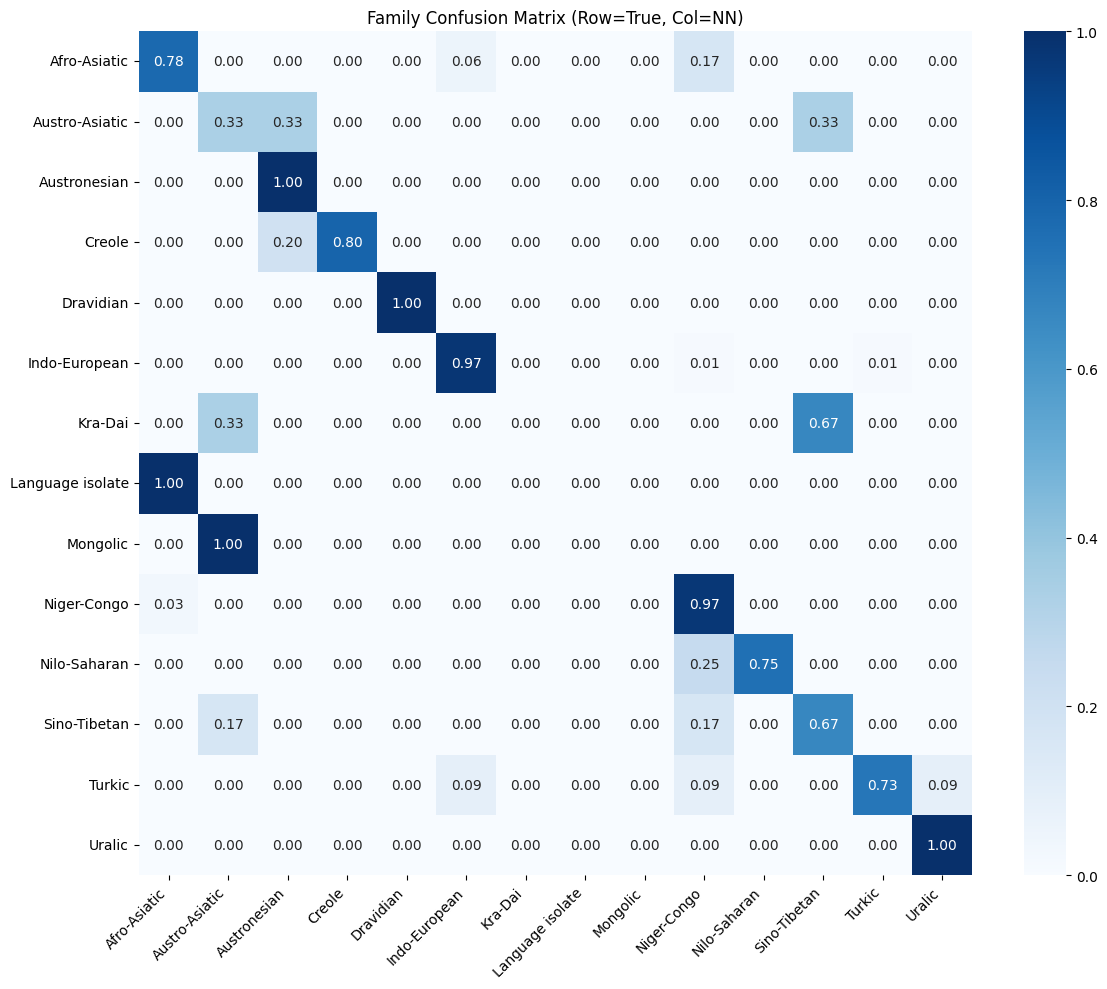

In [9]:
# Family Confusion Matrix
print("\n--- Family Confusion Matrix (Top 15 Families) ---")
y_true = []
y_pred = []
for i in range(len(metadata)):
    nn_idx = np.argmin(dists[i])
    y_true.append(metadata.iloc[i]["family"])
    y_pred.append(metadata.iloc[nn_idx]["family"])

top_families = metadata["family"].value_counts().head(15).index
mask = [t in top_families and p in top_families for t, p in zip(y_true, y_pred)]
y_true_filt = [t for i, t in enumerate(y_true) if mask[i]]
y_pred_filt = [p for i, p in enumerate(y_pred) if mask[i]]
labels = sorted(list(set(y_true_filt)))
cm = confusion_matrix(y_true_filt, y_pred_filt, labels=labels, normalize='true')

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.title("Family Confusion Matrix (Row=True, Col=NN)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Final Visualization: Tuned HDBSCAN on UMAP
if "UMAP1" in metadata.columns and "hdbscan_tuned" in metadata.columns:
    fig = go.Figure()
    # Clusters
    mask = metadata["hdbscan_tuned"] != -1
    fig.add_trace(go.Scatter(
        x=metadata.loc[mask, "UMAP1"],
        y=metadata.loc[mask, "UMAP2"],
        mode='markers',
        marker=dict(
            size=8,
            color=metadata.loc[mask, "hdbscan_tuned"],
            colorscale='Turbo',
            opacity=0.8,
            showscale=False
        ),
        text=metadata.loc[mask, "name"],
        customdata=metadata.loc[mask, ["UMAP1", "UMAP2", "hdbscan_tuned", "family", "resource_category"]],
        hovertemplate="<b>%{hovertext}</b><br>Cluster: %{customdata[2]}<br>Family: %{customdata[3]}<extra></extra>",
        name='Clusters'
    ))
    # Noise
    mask_noise = metadata["hdbscan_tuned"] == -1
    fig.add_trace(go.Scatter(
        x=metadata.loc[mask_noise, "UMAP1"],
        y=metadata.loc[mask_noise, "UMAP2"],
        mode='markers',
        marker=dict(
            size=6,
            color='lightgrey',
            opacity=0.4
        ),
        text=metadata.loc[mask_noise, "name"],
        customdata=metadata.loc[mask_noise, ["UMAP1", "UMAP2", "hdbscan_tuned", "family", "resource_category"]],
        hovertemplate="<b>%{hovertext}</b> (Noise)<br>Family: %{customdata[3]}<extra></extra>",
        name='Noise'
    ))
    fig.update_layout(
        title="Tuned HDBSCAN Clustering on UMAP",
        width=1000,
        height=700,
        hoverlabel=dict(bgcolor="white", font_size=12)
    )
    fig.show()

# Cluster → languages → size
for cid, group in metadata.groupby("hdbscan_tuned"):
    langs = group["language"].unique()
    size = len(group)
    print(f"Cluster {cid}: {size} items | Languages: {list(langs)}")


KeyError: 'Column not found: language'

In [11]:
# Final Selection: 4 Distinct Clusters from 8
print("\n--- Final Selection: 4 Distinct Clusters from 8 ---")

# 1. Force K=8
kmeans_8 = KMeans(n_clusters=8, init="k-means++", n_init="auto", random_state=42)
labels_8 = kmeans_8.fit_predict(X)
metadata["cluster_8"] = labels_8

# 2. Calculate Density (Silhouette) per Cluster
sil_samples = silhouette_samples(X, labels_8)
metadata["silhouette_8"] = sil_samples

cluster_stats = []
for k in range(8):
    members = metadata[metadata["cluster_8"] == k]
    if len(members) >= 4:  # Ensure enough candidates
        avg_sil = members["silhouette_8"].mean()
        cluster_stats.append({"id": k, "density": avg_sil, "size": len(members)})

# 3. Pick Top 4 Distinct (Dense) Clusters
cluster_stats.sort(key=lambda x: x["density"], reverse=True)
top_4 = cluster_stats[:4]
print("Top 4 Distinct Clusters (from 8):")
for c in top_4:
    print(f"Cluster {c['id']}: Density={c['density']:.4f}, Size={c['size']}")

# 4. Select 4 Languages per Cluster (Medoid + 3 Farthest)
selected_indices = []
for c in top_4:
    cid = c["id"]
    indices = metadata[metadata["cluster_8"] == cid].index.tolist()
    
    # Simple Farthest Point Sampling
    # Start with medoid
    cluster_emb = X[indices]
    center = cluster_emb.mean(axis=0)
    dists_to_center = pairwise_distances(cluster_emb, center.reshape(1, -1)).flatten()
    medoid_idx = indices[np.argmin(dists_to_center)]
    selected = [medoid_idx]
    
    while len(selected) < 4:
        rem = list(set(indices) - set(selected))
        if not rem: break
        dists = pairwise_distances(X[rem], X[selected])
        min_dists = dists.min(axis=1)
        next_idx = rem[np.argmax(min_dists)]
        selected.append(next_idx)
    
    selected_indices.extend(selected)

final_selection = metadata.loc[selected_indices, ["name", "family", "resource_category", "cluster_8"]]
print("\nFinal Selection (4x4):")
print(final_selection)


--- Final Selection: 4 Distinct Clusters from 8 ---
Top 4 Distinct Clusters (from 8):
Cluster 2: Density=0.2591, Size=27
Cluster 0: Density=0.1666, Size=32
Cluster 3: Density=0.1459, Size=4
Cluster 4: Density=0.1086, Size=35

Final Selection (4x4):
                             name                family resource_category  \
102                        Nyanja           Niger-Congo               low   
173                           Fon           Niger-Congo               low   
65                         Somali          Afro-Asiatic               low   
160      Luo (Kenya and Tanzania)          Nilo-Saharan               low   
4                          French         Indo-European              high   
19           Modern Greek (1453-)         Indo-European              high   
28                        Catalan         Indo-European              high   
115                          Urdu         Indo-European               low   
178             Nigerian Fulfulde           Niger-Congo  